# Proyecto de Regresión Lineal Múltiple: Predicción de Ventas (Advertising Dataset)

## Objetivo del Proyecto

El objetivo de este proyecto es analizar y modelar la relación simultánea entre la inversión publicitaria en tres medios de comunicación (**Televisión**, **Radio** y **Periódico**) y las **Ventas** generadas de un producto.

A través de un modelo de **Regresión Lineal Múltiple**, se busca:

1. Evaluar el impacto conjunto e individual de cada canal publicitario sobre la variable respuesta (`sales`).

2. Cuantificar el retorno de inversión publicitaria por cada mil dólares destinados a cada medio.

3. Generar un modelo predictivo capaz de estimar las ventas futuras según la asignación presupuestaria.

> **Aclaración sobre las unidades de medida en el dataset:**
> * **Inversión publicitaria (`TV`, `radio`, `newspaper`):** Miles de dólares (USD). Por ejemplo, un valor de `230.1` equivale a **USD \$230.100**.

> * **Ventas (`sales`):** Miles de unidades. Por ejemplo, un valor de `22.1` equivale a **22.100 unidades vendidas**.

> * **Regla de interpretación:** Para obtener los valores en escala real de negocio, cualquier dato del dataset o resultado numérico del modelo debe multiplicarse por **1.000**.

## Importación de Librerías

Para comenzar, cargamos las librerías necesarias para la manipulación de datos, visualización y posterior modelado.

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    explained_variance_score,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)
from sklearn.model_selection import train_test_split

# Estilo gráfico
sns.set_theme(style="whitegrid")

Carga y Exploración Inicial del Dataset

Primero, cargamos el archivo `Advertising.csv` y observamos los primeros 5 registros para entender con qué datos nos encontramos.

In [3]:
df = pd.read_csv('../Datos/Advertising.csv')
df.head()

,Unnamed: 0,TV,radio,newspaper,sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


Al revisar las primeras filas, notamos que existe una columna llamada `Unnamed: 0` que simplemente actúa como un índice duplicado e innecesario. Procedemos a eliminarla.

In [4]:
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])

df.head()

,TV,radio,newspaper,sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


Ahora que la estructura está más limpia, chequeamos los tipos de datos de cada columna y verificamos si existen valores nulos.

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   radio      200 non-null    float64
 2   newspaper  200 non-null    float64
 3   sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


Aunque al tratarse de variables continuas con varios decimales es poco probable encontrar registros idénticos, chequeamos rápidamente si existen filas duplicadas en el conjunto de datos para garantizar la integridad de los datos.

In [6]:
df.duplicated().sum()

np.int64(0)

Como el resultado es `0`, confirmamos que no existen duplicados. Ahora pasamos a revisar un resumen estadístico básico para entender los rangos, promedios y la dispersión de los datos.

In [7]:
df.describe()

,TV,radio,newspaper,sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14.022500
std,85.854236,14.846809,21.778621,5.217457
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,10.375000
50%,149.750000,22.900000,25.750000,12.900000
75%,218.825000,36.525000,45.100000,17.400000
max,296.400000,49.600000,114.000000,27.000000


## Análisis Exploratorio de Datos (EDA)

Para comenzar el análisis exploratorio, primero generamos **gráficos de dispersión (scatterplots)** individuales.

Esto nos permite tener una primera aproximación visual y observar cómo se distribuyen los puntos de inversión en cada medio frente a las ventas.

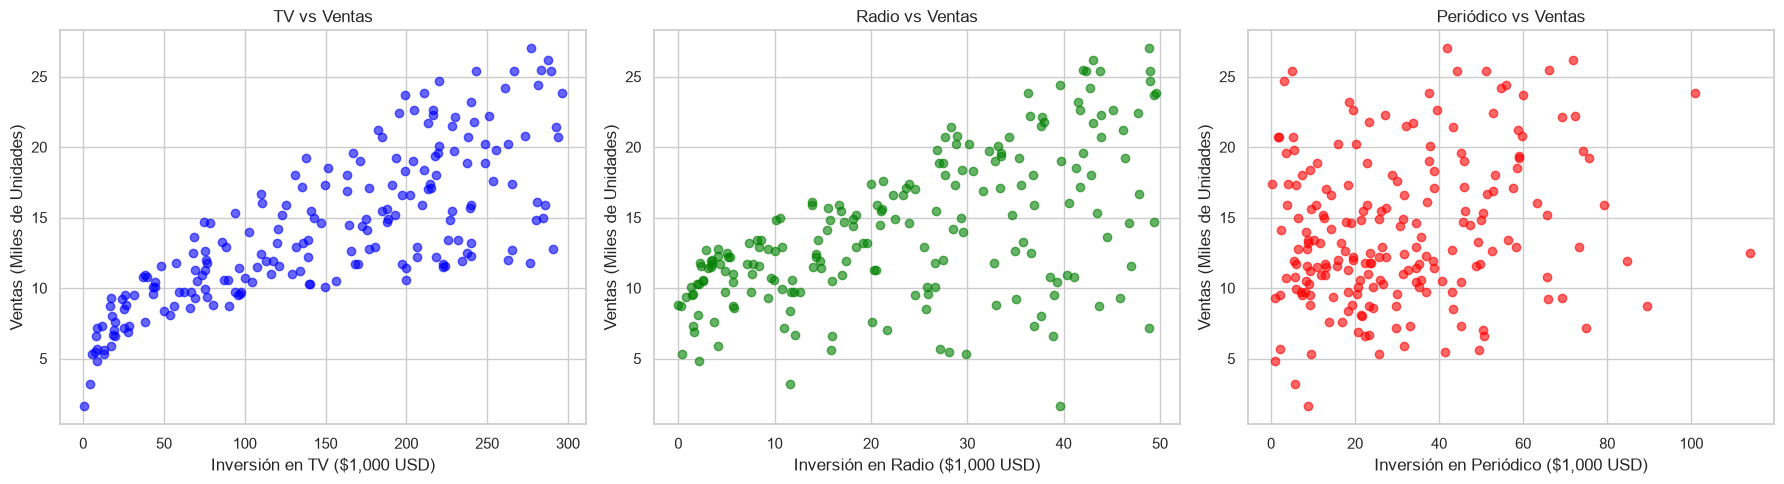

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Scatterplot TV vs Ventas
axes[0].scatter(df['TV'], df['sales'], color='blue', alpha=0.6)
axes[0].set_title('TV vs Ventas')
axes[0].set_xlabel('Inversión en TV ($1,000 USD)')
axes[0].set_ylabel('Ventas (Miles de Unidades)')

# Scatterplot Radio vs Ventas
axes[1].scatter(df['radio'], df['sales'], color='green', alpha=0.6)
axes[1].set_title('Radio vs Ventas')
axes[1].set_xlabel('Inversión en Radio ($1,000 USD)')
axes[1].set_ylabel('Ventas (Miles de Unidades)')

# Scatterplot Periódico vs Ventas
axes[2].scatter(df['newspaper'], df['sales'], color='red', alpha=0.6)
axes[2].set_title('Periódico vs Ventas')
axes[2].set_xlabel('Inversión en Periódico ($1,000 USD)')
axes[2].set_ylabel('Ventas (Miles de Unidades)')

plt.tight_layout()
plt.show()

A nivel visual, observamos una marcada tendencia positiva y lineal entre `TV` y `sales`, una dispersión positiva en `radio`, y una relación mucho más difusa e inconstante en `newspaper`.

Para verificar y confirmar cuantitativamente lo que acabamos de ver en los gráficos de dispersión, generamos la **matriz de correlación (heatmap)** que nos da los valores numéricos exactos de asociación entre variables.

Quedando: `TV` presenta la mayor correlación positiva con las ventas (`0.782`), seguida por `radio` (`0.576`), mientras que `newspaper` se queda muy por detrás (`0.228`).

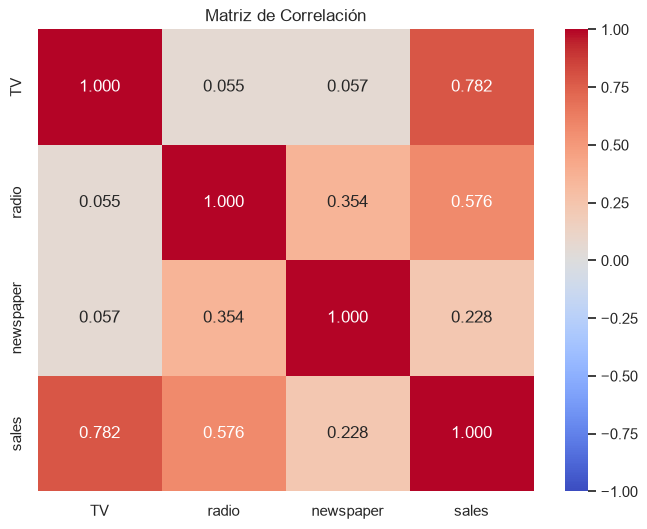

In [9]:
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".3f", vmin=-1, vmax=1)
plt.title('Matriz de Correlación')
plt.show()

## Selección de Variables y División Entrenamiento / Prueba

Con las relaciones visuales y numéricas confirmadas, definimos nuestra matriz de variables explicativas $X$ (`TV`, `radio`, `newspaper`) y la variable objetivo $y$ (`sales`).

Para evitar sobreajuste (overfitting) y evaluar el modelo con datos que nunca ha visto, dividimos el dataset reservando un **80% para entrenamiento** y un **20% para evaluación**.

In [10]:
X = df[['TV', 'radio', 'newspaper']]
y = df['sales']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Muestras de entrenamiento: {X_train.shape[0]}")
print(f"Muestras de prueba: {X_test.shape[0]}")

Muestras de entrenamiento: 160
Muestras de prueba: 40


## Entrenamiento del Modelo

Instanciamos el algoritmo de **Regresión Lineal Múltiple** y lo ajustamos únicamente utilizando el conjunto de entrenamiento (`X_train` e `y_train`).

In [11]:
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](3,)","[0.04,0.19,0. ]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](3,)","['TV','radio','newspaper']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.979
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(3)


Generación de Predicciones y Evaluación del Modelo

Antes de analizar los resultados, evaluamos el desempeño global del modelo sobre el conjunto de prueba utilizando las siguientes métricas de evaluación:

* **MAE (Error Absoluto Medio) = 1.461:** Es el error promedio "real" en las mismas unidades que la variable objetivo. En nuestro caso, significa que el modelo se equivoca en promedio por **1,461 unidades vendidas** ($1.461 \times 1,000$). Es una métrica muy intuitiva y no penaliza en exceso los errores atípicos aislados.

* **MSE (Error Cuadrático Medio) = 3.174:** Es el promedio de los errores al cuadrado. Su gran ventaja es que penaliza con mayor severidad los errores grandes (un error de 10 unidades pesa mucho más que dos errores de 5), lo que ayuda a detectar desvíos severos, aunque al estar elevado al cuadrado pierde la escala original.

* **RMSE (Raíz del Error Cuadrático Medio) = 1.782:** Devuelve el MSE a la escala original. Indica que la desviación estándar de las predicciones es de aprox. **1,782 unidades vendidas**.
* **R² (Coeficiente de Determinación) = 0.899:** Mide qué proporción de la variabilidad de los datos es explicada por el modelo. Un valor de **0.899** indica que la combinación de inversión en TV, Radio y Periódico explica el **89.9%** de las variaciones en las ventas. Esta métrica sí penaliza si el modelo tiene un sesgo sistemático (si se equivoca siempre hacia arriba o hacia abajo).

* **Varianza Explicada (Explained Variance) = 0.900:** Mide cuánta de la dispersión o variabilidad del target captura el modelo (en nuestro caso, un **90.0%**). A diferencia del $R^2$, se enfoca únicamente en la dispersión de los residuos y no penaliza tanto el sesgo constante.

In [12]:
y_pred = model.predict(X_test)

print("Intercepto:", model.intercept_)
print("Coeficientes:", model.coef_)

print("\nEvaluación del modelo (Regresión Múltiple):")
print(f"MAE: {mean_absolute_error(y_test, y_pred):.3f}")
print(f"MSE: {mean_squared_error(y_test, y_pred):.3f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.3f}")
print(f"R²: {r2_score(y_test, y_pred):.3f}")
print(f"Varianza explicada: {explained_variance_score(y_test, y_pred):.3f}")

Intercepto: 2.979067338122629
Coeficientes: [0.04472952 0.18919505 0.00276111]

Evaluación del modelo (Regresión Múltiple):
MAE: 1.461
MSE: 3.174
RMSE: 1.782
R²: 0.899
Varianza explicada: 0.900


## Análisis de Residuos

Calculamos los residuos (la diferencia entre el valor real y nuestra predicción) y los graficamos.

Buscamos que los puntos estén distribuidos de forma aleatoria alrededor de la línea cero, sin formar patrones claros (embudos o curvas), lo que confirmaría que el modelo no tiene un sesgo sistemático.

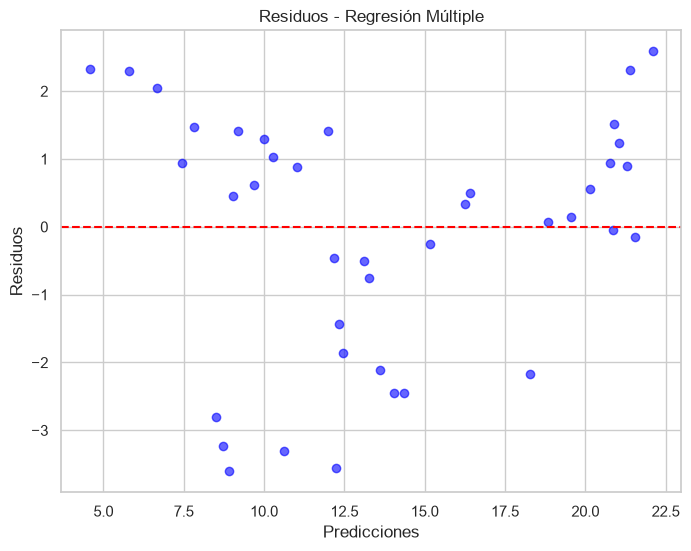

In [13]:
residuos = y_test - y_pred

plt.figure(figsize=(8, 6))
plt.scatter(y_pred, residuos, color='blue', alpha=0.6)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Predicciones")
plt.ylabel("Residuos")
plt.title("Residuos - Regresión Múltiple")
plt.show()

## Gráfico de Ajuste del Modelo (Valores Reales vs Predichos)

Evaluamos visualmente el ajuste en una regresión múltiple graficando los **Datos Reales frente a las Predicciones**. La línea roja diagonal representa el modelo ideal: si el modelo fuera 100% exacto, todos los puntos caerían exactamente sobre esta línea.

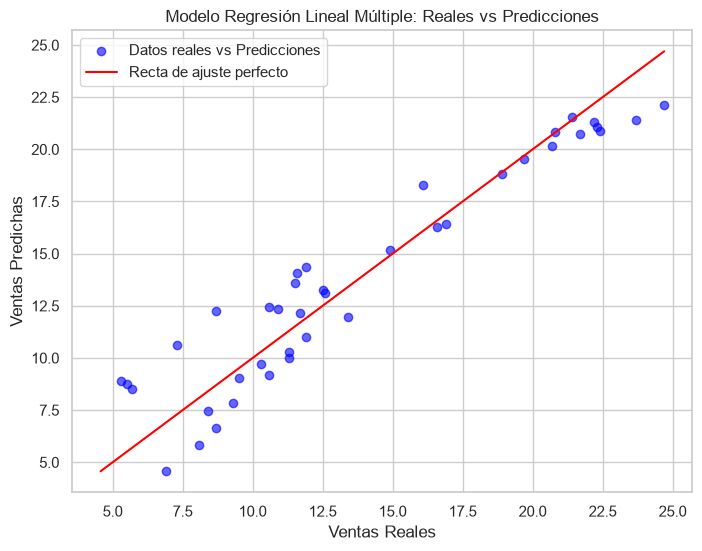

In [14]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, label="Datos reales vs Predicciones", color='blue', alpha=0.6)

# Trazamos la línea de ajuste perfecto (diagonal y=x)
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', label="Recta de ajuste perfecto")

plt.xlabel("Ventas Reales")
plt.ylabel("Ventas Predichas")
plt.legend()
plt.title("Modelo Regresión Lineal Múltiple: Reales vs Predicciones")
plt.show()

## Interpretación de Coeficientes e Inferencia de Negocio

Una vez validado el desempeño global del modelo ($R^2 \approx 89.9\%$), procedemos a analizar el valor del **intercepto** y el peso de cada **coeficiente** ($\beta$) formateados a 3 decimales para comprender la contribución marginal de cada medio publicitario.

In [15]:
print(f"Intercepto (β0): {model.intercept_:.3f}")
print(f"Ventas base estimadas sin inversión: {model.intercept_ * 1000:.2f} unidades\n")

for col, coef in zip(X.columns, model.coef_):
    print(f"Coeficiente {col} (β): {coef:.3f}")
    print(f"-> Por cada $1,000 USD en {col}, las ventas aumentan en {coef * 1000:.2f} unidades.\n")

Intercepto (β0): 2.979
Ventas base estimadas sin inversión: 2979.07 unidades

Coeficiente TV (β): 0.045
-> Por cada $1,000 USD en TV, las ventas aumentan en 44.73 unidades.

Coeficiente radio (β): 0.189
-> Por cada $1,000 USD en radio, las ventas aumentan en 189.20 unidades.

Coeficiente newspaper (β): 0.003
-> Por cada $1,000 USD en newspaper, las ventas aumentan en 2.76 unidades.



### Observaciones sobre el Peso de las Variables

A partir de los coeficientes obtenidos ($\beta_{\text{radio}} = 0.189$, $\beta_{\text{TV}} = 0.045$, $\beta_{\text{newspaper}} = 0.003$), analizamos el comportamiento de cada predictor:

* **Radio:** Muestra el mayor peso e impacto marginal, aportando aproximadamente **189 unidades** vendidas por cada $1,000 USD invertidos.

* **Televisión:** Presenta un impacto constante y significativo, generando cerca de **45 unidades** por cada $1,000 USD.

* **Periódico:** Muestra un rendimiento marginal prácticamente ínfimo en comparación con los otros medios, aportando apenas **2.76 unidades** por cada $1,000 USD.

**Conclusión:**
Dado que el modelo global es robusto ($R^2 \approx 89.9\%$), este desglose nos permite observar cómo influye cada canal.
La marcada diferencia en el rendimiento marginal del periódico frente a la Radio y la TV podría indicar que su uso no está siendo tan eficiente en términos de retorno sobre la inversión dentro de este esquema de medios.